The updated tiled FSPipeline offers a 4x speedup compared to the LopezAcosta2019 version. This makes it possible to do calibration across sets of test cases.


Checking what we can get out of the initial processed results
- FSPipeline with only brightest clouds removed
- New preliminary ice mask
- Can we estimate the location of the landfast ice edge using image variance?
  - Two-pass method -- generate ice and cloud masks, then make an estimated landfast ice mask. Critically, we want to use this as a coastal buffer on the FC image, so that the cluster selection algorithm only chooses sea ice pixels as bright ice. The k-means cluster selection can still access the pixels near the coast.

In [1]:
import skimage.io as io
import skimage
import numpy as np
import pandas as pd
import ultraplot as uplt
import os

In [26]:
dataloc = "../data/MODIS_JOG_example_case/LopezAcosta2019/binary/old_mask_narrow_coast_buffer/"

fs_pipeline_results = os.listdir(dataloc)
fs_pipeline_results = [f for f in fs_pipeline_results if 'png' in f]
fs_pipeline_results.sort()

In [9]:
dataloc

'../data/MODIS_JOG_example_case/'

In [27]:
binary_imgs = [io.imread(dataloc + f) for f in fs_pipeline_results]

In [28]:
all_imgs = np.array(binary_imgs)

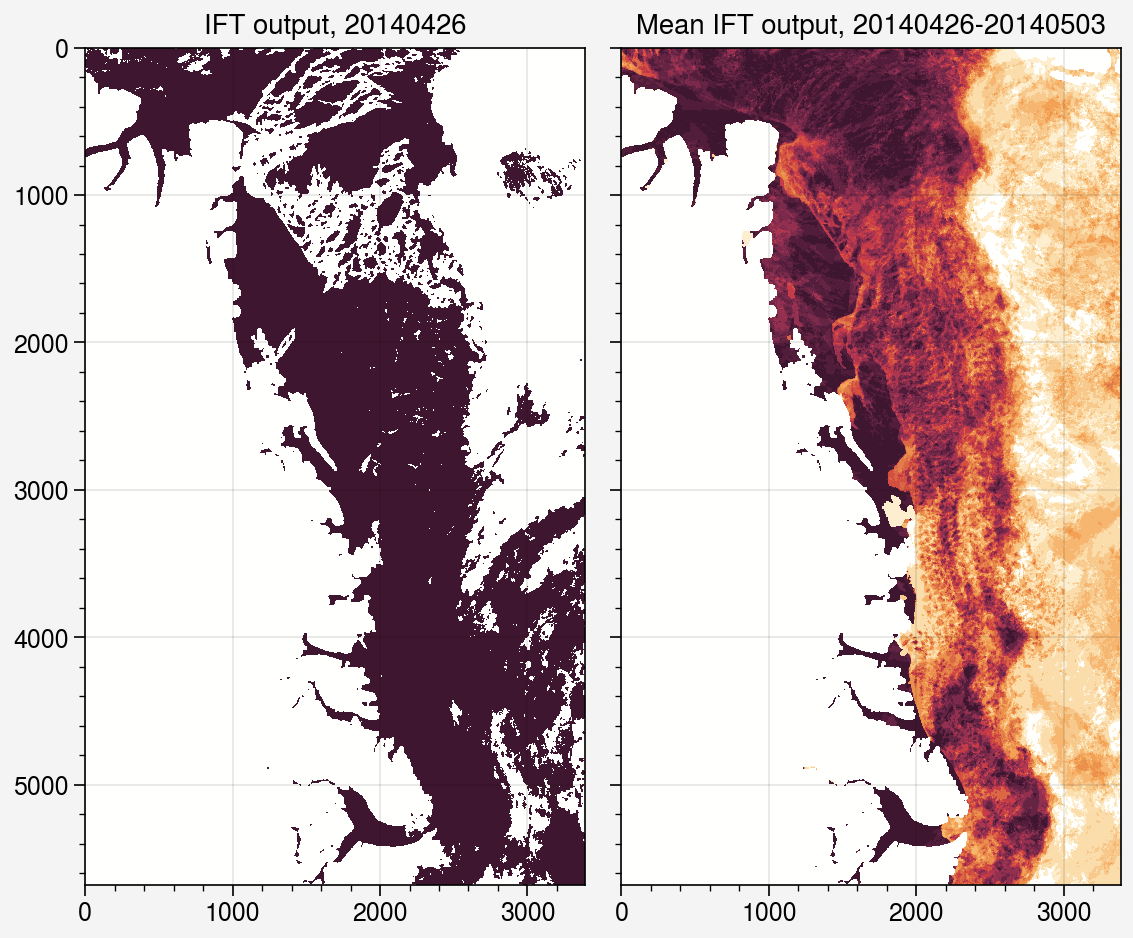

In [30]:
fig, ax = uplt.subplots(ncols=2)
ax[0].imshow(binary_imgs[0])
ax[1].imshow(np.mean(all_imgs, axis=0))
ax[0].format(title="IFT output, " + fs_pipeline_results[0].split('.')[0])
ax[1].format(title="Mean IFT output, " + fs_pipeline_results[0].split('.')[0] + '-' + fs_pipeline_results[-1].split('.')[0])